In [185]:
import pandas as pd
command_data = pd.read_csv('command_data.csv')
# command_all=['net_high_frequency_commands', 'net_low_frequency_commands','process_commands']
# command_all=['grep_commands','find_commands']
# command_all=['grep_commands','find_commands', 'redhat_package_commands']
# command_all=['sed_commands', 'awk_commands']
# command_data = command_data[command_data['command_group'].isin(command_all)]

In [186]:
command_data

,id,command_group,command,description
0,1,docker_swarm_commands,docker swarm init,Initialize a new Docker Swarm
1,2,docker_swarm_commands,docker swarm join --token token manager-ip:port,Join a node to the Swarm using the provided token
2,3,docker_swarm_commands,docker node ls,List all nodes in the Swarm
3,4,docker_swarm_commands,docker node rm node-id,Remove a node from the Swarm by node ID
4,5,docker_swarm_commands,docker service create --name service-name --re...,Create a new service in the Swarm with specifi...
...,...,...,...,...
247,248,redhat_package_commands,sudo dnf remove package_name,Remove a specific package (CentOS 8 and Fedora)
248,249,redhat_package_commands,sudo dnf upgrade,Upgrade all installed packages (CentOS 8 and F...
249,250,redhat_package_commands,sudo rpm -ivh package_name.rpm,Install an .rpm package file
250,251,redhat_package_commands,sudo rpm -e package_name,Remove an installed package


In [187]:
count_data = pd.read_csv('count.csv')
count_data

,id,command_id,command,is_correct
0,4,19,docker service scale nginx_cluster=5,True
1,5,18,docker service ps nginx_cluster,True
2,6,16,docker service create --name nginx_cluster --r...,True
3,7,15,docker swarm init,True
4,8,21,docker service rm nginx_cluster,True
...,...,...,...,...
207,232,182,awk '{sum += $1} END {print sum}',False
208,233,178,sed -n '/pattern/p' file.txt,False
209,234,2,docker swarm join --token token manager-ip:port,False
210,235,8,docker service update --image new-image servic...,False


In [188]:
merged_data = pd.merge(command_data, count_data, left_on='id', right_on='command_id', how='left')
merged_data


,id_x,command_group,command_x,description,id_y,command_id,command_y,is_correct
0,1,docker_swarm_commands,docker swarm init,Initialize a new Docker Swarm,14.0,1.0,docker swarm init,True
1,2,docker_swarm_commands,docker swarm join --token token manager-ip:port,Join a node to the Swarm using the provided token,234.0,2.0,docker swarm join --token token manager-ip:port,False
2,3,docker_swarm_commands,docker node ls,List all nodes in the Swarm,11.0,3.0,docker node ls,True
3,4,docker_swarm_commands,docker node rm node-id,Remove a node from the Swarm by node ID,NaN,NaN,NaN,NaN
4,5,docker_swarm_commands,docker service create --name service-name --re...,Create a new service in the Swarm with specifi...,13.0,5.0,docker service create --name service-name --re...,True
...,...,...,...,...,...,...,...,...
313,248,redhat_package_commands,sudo dnf remove package_name,Remove a specific package (CentOS 8 and Fedora),215.0,248.0,sudo dnf remove package_name,False
314,249,redhat_package_commands,sudo dnf upgrade,Upgrade all installed packages (CentOS 8 and F...,216.0,249.0,sudo dnf upgrade,False
315,250,redhat_package_commands,sudo rpm -ivh package_name.rpm,Install an .rpm package file,219.0,250.0,sudo rpm -ivh package_name.rpm,False
316,251,redhat_package_commands,sudo rpm -e package_name,Remove an installed package,223.0,251.0,sudo rpm -e package_name,False


In [189]:
summary = (
    merged_data.groupby('id_x')
    .agg(
        count_id_x=('id_x', 'count'),
        command_x=('command_x', 'first'),
        des=('description', 'first'),
        total_count=('command_y', 'count'),
        correct_count=('is_correct', lambda x: (x == True).sum())
    )
    .reset_index()
    .sort_values(by=['total_count', 'correct_count'], ascending=[False, True])  # Sort by total_count, then correct_count
).head(12)
print(summary.to_string(index=False))

# summary = merged_data.groupby(['id_x', 'command_x', 'description'])['command_id'].count().reset_index(name='count_num')
# print(summary.to_string(index=False))

 id_x  count_id_x                               command_x                                                             des  total_count  correct_count
   80           3                          strace -p 1234             Trace the system calls of the process with PID 1234            3              1
  130           3                       kubectl get nodes                                   List all nodes in the cluster            3              1
  131           3                  kubectl get namespaces                              List all namespaces in the cluster            3              1
  132           3             kubectl config get-contexts                                         List available contexts            3              1
  129           3                    kubectl cluster-info                                     Display cluster information            3              2
  133           3 kubectl config use-context context_name                                 Switch to 

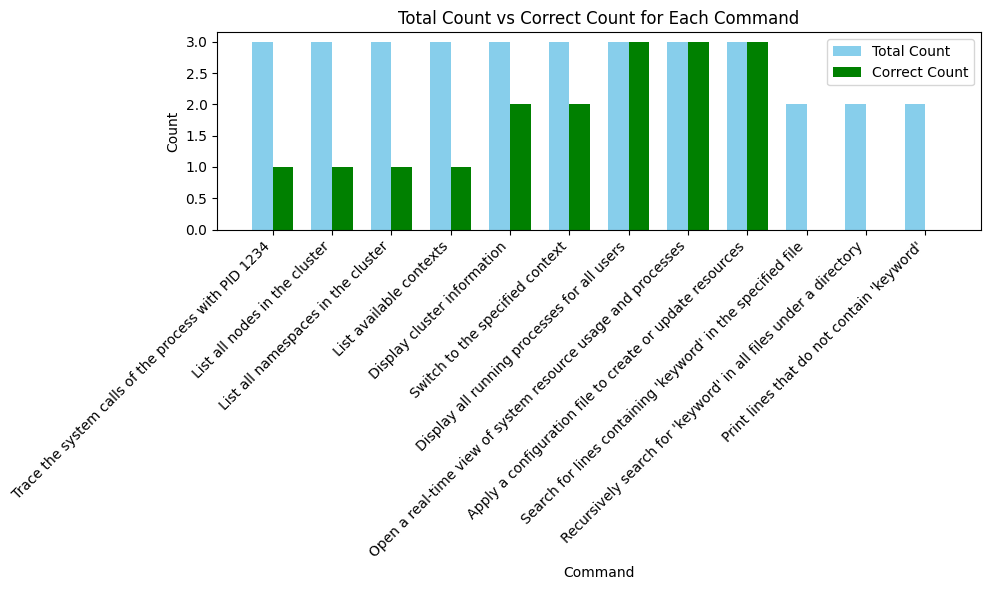

In [190]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# 创建一个条形图，展示 total_count 和 correct_count，不让条形覆盖
import numpy as np

# 设置条形的宽度和位置
bar_width = 0.35
index = np.arange(len(summary['command_x']))

# 画出 total_count 和 correct_count，设置条形不重叠
ax.bar(index, summary['total_count'], width=bar_width, label='Total Count', color='skyblue', align='center')
ax.bar(index + bar_width, summary['correct_count'], width=bar_width, label='Correct Count', color='green', align='center')

# 更新 x 轴标签位置
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary['command_x'], rotation=45, ha='right')

# 设置标签和标题
ax.set_xlabel('Command')
ax.set_ylabel('Count')
ax.set_title('Total Count vs Correct Count for Each Command')
ax.set_xticklabels(summary['des'], rotation=45, ha='right')

# 显示图例
ax.legend()

# 调整布局并显示
plt.tight_layout()
plt.show()


In [191]:
top_10_count = summary.nlargest(10, 'count_num')
print(top_10_count.to_string(index=False))

KeyError: 'count_num'

In [16]:
min_10_count = summary.nsmallest(10, 'count_num')
print(min_10_count.to_string(index=False))


 id_x                               command_x                        description  count_num
  129                    kubectl cluster-info        Display cluster information          2
  130                       kubectl get nodes      List all nodes in the cluster          2
  131                  kubectl get namespaces List all namespaces in the cluster          2
  132             kubectl config get-contexts            List available contexts          2
  133 kubectl config use-context context_name    Switch to the specified context          2
